This code downloads wind data from ERA5.

In [1]:
import cdsapi

c = cdsapi.Client(
    url="https://cds.climate.copernicus.eu/api",
    key="1e9aa134-9779-4ac2-846f-2ab89b57873e"
)

c.retrieve(
    'reanalysis-era5-single-levels-monthly-means',
    {
        'product_type': 'monthly_averaged_reanalysis',
        'variable': [
            '10m_u_component_of_wind',
            '10m_v_component_of_wind',
        ],
        'year': [str(y) for y in range(2015, 2026)],
        'month': [f'{m:02d}' for m in range(1, 13)],
        'time': '00:00',
        'area': [6, 95, -11, 141],
        'format': 'netcdf',
        'grid': '0.25/0.25',
    },
    '/Users/hariaksha/Documents/GitHub/climate-conflict/data/climate/wind/era5_wind_indonesia_2015_2025.nc'
)

2026-06-11 17:33:03,207 INFO [2026-06-11T00:00:00Z] Upcoming essential maintenance sessions on Data Stores underlying infrastructure on 15 June. Service disruption expected. For further details, please [visit our forum announcement](https://forum.ecmwf.int/t/upcoming-essential-maintenance-sessions-on-data-stores-underlying-infrastructure-part-2/150414).


2026-06-11 17:33:03,823 INFO Request ID is 8f121690-940d-4775-9420-01e6923a4707


2026-06-11 17:33:04,049 INFO status has been updated to accepted


2026-06-11 17:33:25,979 INFO status has been updated to running


2026-06-11 17:33:37,940 INFO status has been updated to successful


...

89c9f887d919e74c1b95d60b5e91e5b8.nc:  28%|██▊       | 2.00M/7.24M [00:01<00:03, 1.64MB/s]

89c9f887d919e74c1b95d60b5e91e5b8.nc:  55%|█████▌    | 4.00M/7.24M [00:01<00:00, 3.77MB/s]

89c9f887d919e74c1b95d60b5e91e5b8.nc:  83%|████████▎ | 6.00M/7.24M [00:01<00:00, 5.15MB/s]

89c9f887d919e74c1b95d60b5e91e5b8.nc: 100%|██████████| 7.24M/7.24M [00:01<00:00, 6.15MB/s]

'/Users/hariaksha/Documents/GitHub/climate-conflict/data/climate/wind/era5_wind_indonesia_2015_2025.nc'

## 1. Imports and configuration

All paths are relative to wherever you run the notebook. Set `DATA_DIR` to the folder containing your fire CSV and ACLED xlsx.

In [2]:
import warnings
import re
import difflib
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pyfixest as pf
from pathlib import Path
from scipy.spatial import cKDTree

warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────
WIND_NC     = '/Users/hariaksha/Documents/GitHub/climate-conflict/data/climate/wind/era5_wind_indonesia_2015_2025.nc'
FIRE_CSV    = '/Users/hariaksha/Documents/GitHub/climate-conflict/data/climate/fire/DL_FIRE_SUOMI-VIIRS-C2_718931_Nov2000-Feb2026_buffer0km-csv/fire_archive_SV-C2_718931.csv'
ACLED_XLSX  = '/Users/hariaksha/Documents/GitHub/climate-conflict/data/unrest/ACLED Data_2026-06-10.xlsx'
DISTRICT_SHP = '/Users/hariaksha/Documents/GitHub/climate-conflict/data/administrative/gadm41_IDN_shp/gadm41_IDN_2.shp'

# ── Parameters ────────────────────────────────────────────────────────────
UPWIND_RADIUS_KM  = 300   # search radius for upwind fires
UPWIND_HALF_ANG   = 45    # ± degrees from upwind direction
START_YEAR        = 2015
END_YEAR          = 2025
END_MONTH         = 6
N_LAGS            = 1 # controls how many monthly lags of fire exposure to include as additional regressors in model
R_EARTH           = 6371.0  # km, for distance conversions

POLITICAL_VIOLENCE = [
    'Riots', 'Violence against civilians',
    'Battles', 'Explosions/Remote violence',
]

print('All imports OK')

All imports OK


## 1b. Load district (kabupaten/kota) boundaries

We use GADM41 admin2 polygons (502 districts) as the spatial backbone for assigning fire
detections and wind grid cells to districts, and for computing district centroids used in
the upwind instrument. This replaces the earlier ACLED-bounding-box approach with true
point-in-polygon spatial joins.

In [3]:
districts_gdf = gpd.read_file(DISTRICT_SHP)[['NAME_1', 'NAME_2', 'geometry']].rename(
    columns={'NAME_1': 'province', 'NAME_2': 'district'}
)

# A handful of district names are duplicated across provinces (e.g. "Banjar" exists in
# both West Java and South Kalimantan). Disambiguate so `district` is a unique key.
dup_mask = districts_gdf['district'].duplicated(keep=False)
districts_gdf.loc[dup_mask, 'district'] = (
    districts_gdf.loc[dup_mask, 'district'] + ' (' + districts_gdf.loc[dup_mask, 'province'] + ')'
)

# Representative point (guaranteed inside the polygon, even for archipelagos) used as
# the district "centroid" for the upwind-instrument bearing/distance calculations.
rep_points = districts_gdf.geometry.representative_point()
districts_gdf['dist_lat'] = rep_points.y
districts_gdf['dist_lon'] = rep_points.x

district_to_prov = dict(zip(districts_gdf['district'], districts_gdf['province']))

print(f'Districts loaded: {len(districts_gdf):,}')
print(districts_gdf[['province', 'district', 'dist_lat', 'dist_lon']].head())

Districts loaded: 502
  province         district  dist_lat   dist_lon
0     Aceh       Aceh Barat  4.451205  96.200535
1     Aceh  Aceh Barat Daya  3.835823  96.847922
2     Aceh       Aceh Besar  5.354748  95.496192
3     Aceh        Aceh Jaya  4.810597  95.698874
4     Aceh     Aceh Selatan  3.070028  97.468794


## 2. Load ERA5 wind data and compute wind direction

ERA5 provides:
- **u10**: eastward (positive = blowing east)
- **v10**: northward (positive = blowing north)

We derive the direction the wind is **blowing from** (meteorological convention, degrees clockwise from north), and wind speed. These are aggregated to province level by averaging over grid cells within each province's bounding box.

In [4]:
ds = xr.open_dataset(WIND_NC)
print('Wind dataset variables:', list(ds.data_vars))
print('Dimensions:', dict(ds.dims))
print('Time range:', ds.valid_time.values[[0, -1]] if 'valid_time' in ds
      else ds.time.values[[0, -1]])

# Normalise dimension names
if 'valid_time' in ds.coords:
    ds = ds.rename({'valid_time': 'time'})

# Pull u and v arrays
u_da = ds['u10'] if 'u10' in ds else ds[list(ds.data_vars)[0]]
v_da = ds['v10'] if 'v10' in ds else ds[list(ds.data_vars)[1]]

# Convert to dataframe
u_df = u_da.to_dataframe(name='u10').reset_index()
v_df = v_da.to_dataframe(name='v10').reset_index()
wind_df = u_df.merge(v_df, on=['time', 'latitude', 'longitude'])

# Parse year/month
wind_df['time'] = pd.to_datetime(wind_df['time'])
wind_df['year']  = wind_df['time'].dt.year
wind_df['month'] = wind_df['time'].dt.month
wind_df = wind_df[(wind_df['year'] >= START_YEAR) &
                   ~((wind_df['year'] == END_YEAR) & (wind_df['month'] > END_MONTH))]

# Wind speed and direction
wind_df['wind_speed']    = np.sqrt(wind_df['u10']**2 + wind_df['v10']**2)
wind_df['wind_dir_from'] = (np.degrees(np.arctan2(wind_df['u10'],
                                                    wind_df['v10'])) + 180) % 360

print(f'\nWind grid points per month: {wind_df.groupby(["year","month"]).size().mean():.0f}')
print(f'Wind speed  — mean: {wind_df.wind_speed.mean():.2f} m/s  '
      f'max: {wind_df.wind_speed.max():.2f} m/s')
print(wind_df[['latitude','longitude','year','month',
               'u10','v10','wind_speed','wind_dir_from']].head())

Wind dataset variables: ['u10', 'v10']
Dimensions: {'valid_time': 132, 'latitude': 69, 'longitude': 185}
Time range: ['2015-01-01T00:00:00.000000000' '2025-12-01T00:00:00.000000000']



Wind grid points per month: 12765
Wind speed  — mean: 2.85 m/s  max: 10.25 m/s
   latitude  longitude  year  month       u10       v10  wind_speed  \
0       6.0      95.00  2015      1 -5.425678 -0.700418    5.470701   
1       6.0      95.25  2015      1 -5.431049 -0.367411    5.443463   
2       6.0      95.50  2015      1 -5.124897  0.068624    5.125357   
3       6.0      95.75  2015      1 -4.750385  0.175558    4.753628   
4       6.0      96.00  2015      1 -4.547749  0.045187    4.547973   

   wind_dir_from  
0      82.644188  
1      86.129837  
2      90.767174  
3      92.116501  
4      90.569283  


## 3. Load ACLED conflict data

We aggregate events to district-month for two outcomes:
- **events**: all ACLED event types
- **pv_events**: political violence only (riots, battles, violence against civilians, explosions)

ACLED's `admin2` field uses English-translated district names (e.g. "East Jakarta"),
while the GADM district polygons use Indonesian names (e.g. "Jakarta Timur"). We build a
mapping between the two naming conventions (direct match → manual overrides for known
renames → directional-word translation rules), then aggregate conflict to the matched
GADM districts. A small number of ACLED districts (mostly post-2014 "pemekaran"
regencies not present in GADM 4.1) cannot be matched and are dropped.

In [5]:
# ── Map ACLED admin2 names to GADM district names ──────────────────────────
DIR_MAP = {
    'North': 'Utara', 'South': 'Selatan', 'East': 'Timur', 'West': 'Barat',
    'Central': 'Tengah', 'Southeast': 'Tenggara', 'Southwest': 'Barat Daya',
}

# Known renames between ACLED's English names and GADM's Indonesian names that
# the directional-translation rules below can't handle automatically.
ADMIN2_OVERRIDES = {
    'Yogyakarta': 'Kota Yogyakarta',
    'Medan': 'Kota Medan',
    'Bukit Tinggi': 'Bukittinggi',
    'Pematang Siantar': 'Pematangsiantar',
    'Tanjung Pinang': 'Tanjungpinang',
    'Padang Sidempuan': 'Padangsidimpuan',
    'Sawah Lunto': 'Sawahlunto',
    'Sawahlunto Sijunjung': 'Sijunjung',
    'Tebing Tinggi': 'Tebingtinggi',
    'Pangkajene and Islands': 'Pangkajene Dan Kepulauan',
    'East Tanjung Jabung': 'Tanjung Jabung T',
    'West Tanjung Jabung': 'Tanjung Jabung B',
    'South Central Timor': 'Timor Tengah Selatan',
    'North Central Timor': 'Timor Tengah Utara',
    'East Kolaka': 'Kolaka',
    'North Labuhan Batu': 'Labuhanbatu Utara',
    'Labuhan Batu': 'Labuhanbatu',
    'Tulang Bawang': 'Tulangbawang',
    'Lima Puluh': 'Lima Puluh Kota',
    'Central Jakarta': 'Jakarta Pusat',
    'Banggai Islands': 'Banggai Kepulauan',
    'Baru': 'Barru',
    'Baubau': 'Bau-Bau',
}


def build_admin2_map(acled_names, gadm_names):
    """Map ACLED admin2 names to GADM district names.

    Resolution order: direct match -> manual override -> directional-word /
    "X Islands" translation rules. Names that still don't resolve are left
    unmapped (returned in `unmatched`).
    """
    mapping = {}
    unmatched = []
    for name in acled_names:
        if name in gadm_names:
            mapping[name] = name
            continue
        override = ADMIN2_OVERRIDES.get(name)
        if override and override in gadm_names:
            mapping[name] = override
            continue

        candidates = []
        m = re.match(r'^(.*) Islands$', name)
        if m:
            candidates.append(f'Kepulauan {m.group(1)}')
        for en, idn in DIR_MAP.items():
            m = re.match(rf'^{en} (.*)$', name)
            if m:
                candidates.append(f'{m.group(1)} {idn}')

        found = next((c for c in candidates if c in gadm_names), None)
        if found:
            mapping[name] = found
        else:
            unmatched.append(name)
    return mapping, unmatched


acled = pd.read_excel(
    ACLED_XLSX,
    usecols=['event_date','admin1','admin2','event_type','fatalities',
             'latitude','longitude']
)
acled['event_date'] = pd.to_datetime(acled['event_date'])
acled['year']       = acled['event_date'].dt.year
acled['month']      = acled['event_date'].dt.month
acled['is_pv']      = acled['event_type'].isin(POLITICAL_VIOLENCE)

acled_admin2_names = acled['admin2'].dropna().unique()
gadm_district_names = set(districts_gdf['district'])
admin2_map, unmatched_districts = build_admin2_map(acled_admin2_names, gadm_district_names)

acled['district'] = acled['admin2'].map(admin2_map)
n_before = len(acled)
acled_matched = acled.dropna(subset=['district']).copy()
n_after = len(acled_matched)

print(f'ACLED admin2 districts: {len(acled_admin2_names)}  |  '
      f'matched to GADM: {len(admin2_map)}  |  unmatched: {len(unmatched_districts)}')
print(f'ACLED events retained: {n_after:,}/{n_before:,} '
      f'({n_after/n_before*100:.1f}%)')
print(f'Unmatched districts (dropped): {sorted(unmatched_districts)}')

conflict_pm = (
    acled_matched.groupby(['district','year','month'])
    .agg(events=('event_type','count'),
         pv_events=('is_pv','sum'),
         fatalities=('fatalities','sum'))
    .reset_index()
)

print(f'\nDistricts with conflict data: {conflict_pm["district"].nunique()}')
print(f'All events: {n_after:,}  |  '
      f'Political violence: {acled_matched["is_pv"].sum():,} '
      f'({acled_matched["is_pv"].mean()*100:.1f}%)')
print(conflict_pm.head())

ACLED admin2 districts: 469  |  matched to GADM: 449  |  unmatched: 20
ACLED events retained: 21,393/21,703 (98.6%)
Unmatched districts (dropped): ['Banjar', 'Binjai', 'Central Buton', 'Central Mamuju', 'Konawe Islands', 'Malaka', 'Mempawah', 'North Morowali', 'North Musi Rawas', 'Pangandaran', 'Pegunungan Arfak', 'Penukal Abab Lematang Ilir', 'Pulau Taliabu', 'Sitaro Islands', 'South Buton', 'South Manokwari', 'Tanjung Balai', 'Thousand Islands', 'West Muna', 'West Pesisir']

Districts with conflict data: 447
All events: 21,393  |  Political violence: 3,510 (16.4%)
     district  year  month  events  pv_events  fatalities
0  Aceh Barat  2015      7       2          0           0
1  Aceh Barat  2016      5       1          0           0
2  Aceh Barat  2016      6       1          0           0
3  Aceh Barat  2017      8       1          0           0
4  Aceh Barat  2017      9       1          0           0


## 4. Load and filter fire data

Filters applied:
- `type == 0`: vegetation fires only (drops volcanoes, industrial heat sources)
- `confidence in ['h', 'n']`: high and nominal confidence only (drops low-confidence detections)

Each fire detection retains its exact lat/lon, which is needed for the upwind instrument
construction in the next step. Fires are assigned to districts via a point-in-polygon
spatial join against the GADM district polygons.

In [6]:
fires_raw = pd.read_csv(
    FIRE_CSV,
    usecols=['acq_date','latitude','longitude','frp','confidence','type'],
    dtype={'confidence': str, 'type': int}
)
print(f'Raw detections: {len(fires_raw):,}')

fires = fires_raw[
    (fires_raw['type'] == 0) &
    (fires_raw['confidence'].isin(['h','n']))
].copy()
print(f'After type=0 and confidence h/n: {len(fires):,} '
      f'({len(fires)/len(fires_raw)*100:.1f}% retained)')

fires['acq_date'] = pd.to_datetime(fires['acq_date'])
fires['year']     = fires['acq_date'].dt.year
fires['month']    = fires['acq_date'].dt.month
fires = fires[
    (fires['year'] >= START_YEAR) &
    ~((fires['year'] == END_YEAR) & (fires['month'] > END_MONTH))
]
print(f'After date filter: {len(fires):,}')

# Assign fires to districts via point-in-polygon spatial join
fires_gdf = gpd.GeoDataFrame(
    fires,
    geometry=gpd.points_from_xy(fires['longitude'], fires['latitude']),
    crs='EPSG:4326'
)
fires_joined = gpd.sjoin(
    fires_gdf, districts_gdf[['district','geometry']],
    how='left', predicate='within'
)
fires['district'] = fires_joined['district'].values
n_before = len(fires)
fires = fires.dropna(subset=['district']).copy()
print(f'After district assignment: {len(fires):,}/{n_before:,} '
      f'({len(fires)/n_before*100:.1f}% fall within a district polygon)')

# District-month fire totals (the endogenous treatment variable)
fires_pm = (
    fires.groupby(['district','year','month'])
    .agg(n_fires=('frp','size'), total_frp=('frp','sum'))
    .reset_index()
)
fires_pm['log_frp']     = np.log1p(fires_pm['total_frp'])
fires_pm['log_n_fires'] = np.log1p(fires_pm['n_fires'])

print(f'\nDistrict-month fire obs: {len(fires_pm):,}')
print(f'Districts with fire:     {fires_pm["district"].nunique()}')

Raw detections: 3,514,520


After type=0 and confidence h/n: 3,140,194 (89.3% retained)


After date filter: 2,038,664


After district assignment: 2,035,256/2,038,664 (99.8% fall within a district polygon)



District-month fire obs: 36,465
Districts with fire:     496


## 5. Aggregate wind to district level

Each ERA5 grid cell (0.25°×0.25°) is assigned to the district whose polygon contains it
via a spatial join. Districts smaller than the grid resolution (no grid point falls
inside their polygon) instead use the nearest grid point to their centroid. For each
district-month, we then average u10 and v10 over all grid cells assigned to that
district to get its representative wind direction and speed.

In [7]:
# Unique ERA5 grid points -> district via spatial join
grid_points = wind_df[['latitude','longitude']].drop_duplicates().reset_index(drop=True)
grid_gdf = gpd.GeoDataFrame(
    grid_points,
    geometry=gpd.points_from_xy(grid_points['longitude'], grid_points['latitude']),
    crs='EPSG:4326'
)
grid_joined = gpd.sjoin(
    grid_gdf, districts_gdf[['district','geometry']],
    how='left', predicate='within'
)
grid_points['district'] = grid_joined['district'].values

# Districts with no grid point inside (smaller than the 0.25° grid) fall back to the
# nearest grid point to their centroid.
districts_with_grid = set(grid_points['district'].dropna().unique())
missing = districts_gdf[~districts_gdf['district'].isin(districts_with_grid)]

if len(missing):
    grid_tree = cKDTree(grid_points[['latitude','longitude']].values)
    _, nn_idx = grid_tree.query(missing[['dist_lat','dist_lon']].values)
    fallback_rows = grid_points.iloc[nn_idx][['latitude','longitude']].reset_index(drop=True).copy()
    fallback_rows['district'] = missing['district'].values
    grid_points = pd.concat([grid_points.dropna(subset=['district']), fallback_rows], ignore_index=True)
else:
    grid_points = grid_points.dropna(subset=['district'])

print(f'Grid points: {len(grid_points):,}  |  districts with assigned wind: {grid_points["district"].nunique()}  '
      f'(of which {len(missing)} via nearest-point fallback)')

# Aggregate wind to district-month (a grid point can feed multiple small districts)
district_wind = wind_df.merge(
    grid_points[['latitude','longitude','district']],
    on=['latitude','longitude'], how='inner'
)
district_wind = (
    district_wind.groupby(['district','year','month'])
    .agg(u10_mean=('u10','mean'), v10_mean=('v10','mean'))
    .reset_index()
)
district_wind['wind_speed']    = np.sqrt(district_wind['u10_mean']**2 +
                                          district_wind['v10_mean']**2)
district_wind['wind_dir_from'] = (
    np.degrees(np.arctan2(district_wind['u10_mean'],
                           district_wind['v10_mean'])) + 180
) % 360

print(f'\nDistrict-month wind obs: {len(district_wind):,}')
print('Sample:')
print(district_wind.head())

Grid points: 2,559  |  districts with assigned wind: 502  (of which 94 via nearest-point fallback)


District-month wind obs: 63,252
Sample:
     district  year  month  u10_mean  v10_mean  wind_speed  wind_dir_from
0  Aceh Barat  2015      1 -0.446088  0.011007    0.446224      91.413506
1  Aceh Barat  2015      2 -0.251730 -0.105286    0.272861      67.302956
2  Aceh Barat  2015      3 -0.272649 -0.006252    0.272721      88.686424
3  Aceh Barat  2015      4 -0.264713 -0.045231    0.268549      80.303612
4  Aceh Barat  2015      5 -0.223798 -0.003197    0.223821      89.181648


## 6. Construct the wind instrument: upwind fire exposure (VECTORISED)

**Instrument definition:** For each district $d$ in month $t$, sum the FRP of all individual fire detections that:
1. Fall within `UPWIND_RADIUS_KM` of the district centroid, **and**
2. Lie within ±`UPWIND_HALF_ANG`° of the direction the wind is blowing **from**

$$Z_{dt} = \sum_{f \in \mathcal{U}_{dt}} \text{FRP}_f$$

where $\mathcal{U}_{dt}$ is the set of fire detections upwind of district $d$ in month $t$.

**Speedup:** We use `scipy.spatial.cKDTree` to index fire coordinates and query for fires within radius, rather than checking all fires against each district. At district resolution this loop runs over roughly 10x more district-months than the province-level version, so it takes several minutes (vs. under a minute at province level).

**Identification logic:**
- Wind direction in a given month is driven by large-scale atmospheric circulation (monsoon system, ENSO phase) — plausibly exogenous to local conflict
- Fires that happen to be burning upwind of a district are more likely to expose that district to smoke, heat displacement, and economic disruption
- This gives an exogenous source of variation in fire exposure

**Exclusion restriction assumption:** Wind direction affects conflict *only through* fire exposure, not through independent channels such as agricultural productivity or rainfall. This is the key assumption to defend in the paper.

In [8]:
def haversine_vectorised(lat1, lon1, lat2_arr, lon2_arr):
    """Distance in km from one point to an array of points."""
    dlat = np.radians(lat2_arr - lat1)
    dlon = np.radians(lon2_arr - lon1)
    a = (np.sin(dlat/2)**2 +
         np.cos(np.radians(lat1)) * np.cos(np.radians(lat2_arr)) *
         np.sin(dlon/2)**2)
    return R_EARTH * 2 * np.arcsin(np.sqrt(a))


def bearing_to(lat1, lon1, lat2_arr, lon2_arr):
    """Bearing (degrees, 0=N, clockwise) from point 1 to each point in array."""
    dlon = np.radians(lon2_arr - lon1)
    x = np.sin(dlon) * np.cos(np.radians(lat2_arr))
    y = (np.cos(np.radians(lat1)) * np.sin(np.radians(lat2_arr)) -
         np.sin(np.radians(lat1)) * np.cos(np.radians(lat2_arr)) * np.cos(dlon))
    return (np.degrees(np.arctan2(x, y)) + 360) % 360


def angular_diff(a, b):
    """Smallest absolute angular difference between two angles (degrees)."""
    return np.minimum(np.abs(a - b) % 360, 360 - np.abs(a - b) % 360)


def lat_lon_to_cartesian(lat, lon):
    """Convert lat/lon to 3D Cartesian coordinates on unit sphere.
    
    This conversion is necessary for accurate spatial indexing near the equator,
    where Euclidean distance in lat/lon space is distorted.
    """
    lat_rad = np.radians(lat)
    lon_rad = np.radians(lon)
    x = np.cos(lat_rad) * np.cos(lon_rad)
    y = np.cos(lat_rad) * np.sin(lon_rad)
    z = np.sin(lat_rad)
    return np.column_stack([x, y, z])


# VECTORISED INSTRUMENT CONSTRUCTION
# Build spatial index from fire coordinates
print('Building spatial index from fire detections...')
fire_lats = fires['latitude'].values
fire_lons = fires['longitude'].values
fire_frps = fires['frp'].values
fire_years = fires['year'].values
fire_months = fires['month'].values

# Convert to 3D Cartesian for efficient distance queries
fire_cart = lat_lon_to_cartesian(fire_lats, fire_lons)
fire_tree = cKDTree(fire_cart)
print(f'  Spatial index built: {len(fire_lats):,} detections')

# District centroids (representative points) for the upwind search
dist_centroids = districts_gdf.set_index('district')[['dist_lat','dist_lon']]

# Build instrument for each district-month
instrument_rows = []
n_dist_months = len(district_wind)

for i, (_, dw) in enumerate(district_wind.iterrows()):
    if (i + 1) % 5000 == 0:
        print(f'  Progress: {i+1:,}/{n_dist_months:,}')
    
    dname = dw['district']
    yr    = int(dw['year'])
    mo    = int(dw['month'])
    wdir  = dw['wind_dir_from']
    
    # District centroid in Cartesian coordinates
    clat, clon = dist_centroids.loc[dname, ['dist_lat','dist_lon']]
    c_cart = lat_lon_to_cartesian(np.array([clat]), np.array([clon]))[0]
    
    # Query tree for all fires within radius
    # Convert km to chord distance: d = 2*R*sin(theta/2), where theta = distance/R
    radius_radians = UPWIND_RADIUS_KM / R_EARTH
    max_chord = 2 * np.sin(radius_radians / 2)
    
    fire_indices = fire_tree.query_ball_point(c_cart, max_chord)
    
    if not fire_indices:
        instrument_rows.append({
            'district': dname, 'year': yr, 'month': mo,
            'upwind_frp': 0.0, 'n_upwind_fires': 0
        })
        continue
    
    # Filter by month
    fire_indices = np.array(fire_indices)
    month_mask = (fire_years[fire_indices] == yr) & (fire_months[fire_indices] == mo)
    month_indices = fire_indices[month_mask]
    
    if len(month_indices) == 0:
        instrument_rows.append({
            'district': dname, 'year': yr, 'month': mo,
            'upwind_frp': 0.0, 'n_upwind_fires': 0
        })
        continue
    
    # Get fire data for this month
    f_lats = fire_lats[month_indices]
    f_lons = fire_lons[month_indices]
    f_frps = fire_frps[month_indices]
    
    # Verify distances with haversine (safety check)
    dists = haversine_vectorised(clat, clon, f_lats, f_lons)
    dist_mask = dists <= UPWIND_RADIUS_KM
    
    if not dist_mask.any():
        instrument_rows.append({
            'district': dname, 'year': yr, 'month': mo,
            'upwind_frp': 0.0, 'n_upwind_fires': 0
        })
        continue
    
    # Filter by distance and wind direction
    f_lats_near = f_lats[dist_mask]
    f_lons_near = f_lons[dist_mask]
    f_frps_near = f_frps[dist_mask]
    
    bearings = bearing_to(clat, clon, f_lats_near, f_lons_near)
    ang_diff = angular_diff(bearings, wdir)
    upwind_mask = ang_diff <= UPWIND_HALF_ANG
    
    instrument_rows.append({
        'district':       dname,
        'year':           yr,
        'month':          mo,
        'upwind_frp':     float(f_frps_near[upwind_mask].sum()),
        'n_upwind_fires': int(upwind_mask.sum()),
    })

instrument_df = pd.DataFrame(instrument_rows)
instrument_df['log_upwind_frp'] = np.log1p(instrument_df['upwind_frp'])

print(f'\nInstrument construction complete!')
print(f'Instrument obs: {len(instrument_df):,}')
print(f'Zero-upwind-fire months: {(instrument_df["upwind_frp"]==0).mean()*100:.1f}%')
print('\nInstrument (log_upwind_frp) summary:')
print(instrument_df['log_upwind_frp'].describe().round(3))

Building spatial index from fire detections...


  Spatial index built: 2,035,256 detections


  Progress: 5,000/63,252


  Progress: 10,000/63,252


  Progress: 15,000/63,252


...

  Progress: 45,000/63,252


  Progress: 50,000/63,252


  Progress: 55,000/63,252


  Progress: 60,000/63,252



Instrument construction complete!
Instrument obs: 63,252
Zero-upwind-fire months: 11.2%

Instrument (log_upwind_frp) summary:
count    63252.000
mean         4.317
std          2.504
min          0.000
25%          2.648
50%          4.431
75%          6.037
max         13.407
Name: log_upwind_frp, dtype: float64


## 7. Build the full IV panel

The panel is balanced across all district-months in 2015–June 2025. It contains:
- **Outcomes**: `events` (all), `pv_events` (political violence)
- **Treatment**: `log_frp` (endogenous, district-month fire intensity)
- **Instrument**: `log_upwind_frp` (exogenous upwind fire exposure)
- **Fixed effects**: district (`district`) and year-month (`year_month`)
- **Lags**: 1 monthly lag of treatment and instrument
- Standard errors are clustered by `province` (the original 38 admin1 units), since the wind instrument is spatially correlated within province but ~450 districts is too granular for defensible clustering

The structural equation being estimated is:

$$E[Y_{dt}] = \exp\left(\alpha_d + \gamma_t + \sum_{k=0}^{1} \beta_k \widehat{\text{logFRP}}_{d,t-k}\right)$$

where $\widehat{\text{logFRP}}$ is the fire intensity instrumented by upwind fire exposure.

In [9]:
all_districts = conflict_pm['district'].unique()
all_ym    = pd.DataFrame(
    [(y, m) for y in range(START_YEAR, END_YEAR + 1)
     for m in range(1, 13)
     if not (y == END_YEAR and m > END_MONTH)],
    columns=['year','month']
)

panel = pd.merge(pd.DataFrame({'district': all_districts}), all_ym, how='cross')

# Merge outcomes
panel = panel.merge(conflict_pm, on=['district','year','month'], how='left')
panel['events']     = panel['events'].fillna(0).astype(int)
panel['pv_events']  = panel['pv_events'].fillna(0).astype(int)
panel['fatalities'] = panel['fatalities'].fillna(0).astype(int)

# Merge treatment
panel = panel.merge(
    fires_pm[['district','year','month','log_frp','log_n_fires']],
    on=['district','year','month'], how='left'
)
panel['log_frp']     = panel['log_frp'].fillna(0)
panel['log_n_fires'] = panel['log_n_fires'].fillna(0)

# Merge instrument
panel = panel.merge(
    instrument_df[['district','year','month','log_upwind_frp']],
    on=['district','year','month'], how='left'
)
panel['log_upwind_frp'] = panel['log_upwind_frp'].fillna(0)

# Merge wind covariates
panel = panel.merge(
    district_wind[['district','year','month','wind_speed','wind_dir_from']],
    on=['district','year','month'], how='left'
)

# Map district -> province for SE clustering
panel['province'] = panel['district'].map(district_to_prov)

# Build lags for treatment and instrument
panel = panel.sort_values(['district','year','month']).reset_index(drop=True)
for lag in range(1, N_LAGS + 1):
    panel[f'log_frp_l{lag}']        = panel.groupby('district')['log_frp'].shift(lag)
    panel[f'log_upwind_frp_l{lag}'] = panel.groupby('district')['log_upwind_frp'].shift(lag)

lag_frp_cols    = [f'log_frp_l{l}'        for l in range(1, N_LAGS + 1)]
lag_upwind_cols = [f'log_upwind_frp_l{l}' for l in range(1, N_LAGS + 1)]
panel = panel.dropna(subset=lag_frp_cols + lag_upwind_cols).reset_index(drop=True)
panel['year_month'] = panel['year'] * 100 + panel['month']

print(f'Panel: {len(panel):,} obs  |  '
      f'{panel["district"].nunique()} districts  |  '
      f'{panel["year_month"].nunique()} time periods')
print(f'Zero-event share (all events):        {(panel["events"]==0).mean()*100:.1f}%')
print(f'Zero-event share (political violence): {(panel["pv_events"]==0).mean()*100:.1f}%')
print(f'\nInstrument coverage (non-zero upwind FRP): '
      f'{(panel["log_upwind_frp"]>0).mean()*100:.1f}%')
print(f'Corr(log_frp, log_upwind_frp): '
      f'{panel["log_frp"].corr(panel["log_upwind_frp"]):.3f}')

Panel: 55,875 obs  |  447 districts  |  125 time periods
Zero-event share (all events):        82.5%
Zero-event share (political violence): 95.8%

Instrument coverage (non-zero upwind FRP): 89.2%
Corr(log_frp, log_upwind_frp): 0.539


## 8. First stage: instrument relevance

Before running the IV, we must verify the instrument is **relevant** — i.e. that upwind fire exposure is a strong predictor of actual district fire intensity after conditioning on fixed effects.

We estimate:
$$\text{logFRP}_{dt} = \alpha_d + \gamma_t + \delta_0 Z_{dt} + \delta_1 Z_{d,t-1} + \eta_{dt}$$

The key diagnostics are:
- **F-statistic on excluded instruments** (Montiel Olea-Pflueger robust F): should exceed 10 (conventional) or ideally 104.7 (5% worst-case bias threshold)
- **Individual t-statistics** on each lag of the instrument
- **First-stage R²** (within)

A weak instrument (F < 10) would mean upwind fire exposure does not meaningfully shift actual fire intensity, and the IV estimates would be unreliable. In that case, the angular cone or radius parameters should be adjusted.

In [10]:
upwind_terms = ' + '.join(['log_upwind_frp'] + lag_upwind_cols)
fs_fml = f'log_frp ~ {upwind_terms} | district + year_month'

print('First stage formula:')
print(f'  {fs_fml}')
print()

fs_res = pf.feols(
    fs_fml,
    data  = panel,
    vcov  = {'CRV1': 'province'},
)
print(fs_res.summary())

# Extract R2 within and N directly from the fitted model
r2_within = fs_res._r2_within
n         = fs_res._N
k         = len(lag_upwind_cols) + 1
f_stat    = (r2_within / k) / ((1 - r2_within) / (n - k - 1))

print(f'\nFirst-stage F-statistic (approx): {f_stat:.2f}')
if f_stat >= 104.7:
    print('  ✓ Strong instrument (F ≥ 104.7: <5% worst-case bias)')
elif f_stat >= 10:
    print('  ~ Acceptable instrument (F ≥ 10), but check MOP robust F')
else:
    print('  ✗ Weak instrument warning (F < 10) — adjust radius or angular cone')

panel['log_frp_hat'] = fs_res.predict()

First stage formula:
  log_frp ~ log_upwind_frp + log_upwind_frp_l1 | district + year_month



###

Estimation:  OLS
Dep. var.: log_frp, Fixed effects: district + year_month
sample: None = all
Inference:  CRV1
Observations:  55875

| Coefficient       |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:------------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| log_upwind_frp    |      0.304 |        0.032 |     9.466 |      0.000 |  0.238 |   0.369 |
| log_upwind_frp_l1 |      0.037 |        0.011 |     3.372 |      0.002 |  0.015 |   0.060 |
---
RMSE: 1.374 R2: 0.63 R2 Within: 0.137 
None

First-stage F-statistic (approx): 4447.16
  ✓ Strong instrument (F ≥ 104.7: <5% worst-case bias)


## 9. Second stage: IV estimates

We estimate four IV specifications:

| Model | Outcome | Treatment |
|-------|---------|----------|
| IV-1 | All events | log(FRP) instrumented by log(upwind FRP) |
| IV-2 | Political violence | log(FRP) instrumented by log(upwind FRP) |
| IV-3 | All events | contemporaneous only (no lags) |
| IV-4 | Political violence | contemporaneous only (no lags) |

In [11]:
fe_str  = 'district + year_month'
vcov    = {'CRV1': 'province'}

# pyfixest only supports a single instrumented (endogenous) regressor, so the
# contemporaneous log_frp is instrumented while its lags enter as exogenous
# controls (still part of the distributed-lag structure, just not instrumented).
endog_var    = 'log_frp'
controls_str = ' + '.join(lag_frp_cols) if lag_frp_cols else '1'
iv_str       = ' + '.join(['log_upwind_frp'] + lag_upwind_cols)

iv_specs = [
    ('IV-1: All events (distributed lags)',
     'events',    controls_str, endog_var, iv_str),
    ('IV-2: Political violence (distributed lags)',
     'pv_events', controls_str, endog_var, iv_str),
    ('IV-3: All events (contemporaneous only)',
     'events',    '1', 'log_frp', 'log_upwind_frp'),
    ('IV-4: Political violence (contemporaneous only)',
     'pv_events', '1', 'log_frp', 'log_upwind_frp'),
]

iv_results  = {}
iv_coef_rows = []

for label, outcome, controls, endog, ivs in iv_specs:
    fml = f'{outcome} ~ {controls} | {fe_str} | {endog} ~ {ivs}'
    print(f'\n── {label} ──')
    print(f'   {fml}')
    try:
        res = pf.feols(fml, data=panel, vcov=vcov)
        print(res.summary())
        iv_results[label] = res

        tidy = res.tidy().reset_index()
        tidy = tidy[tidy['Coefficient'].str.startswith('log_frp')].copy()
        tidy['lag']   = tidy['Coefficient'].str.extract(r'_l(\d+)$').fillna('0').astype(int)
        tidy['IRR']   = np.exp(tidy['Estimate'])
        tidy['model'] = label
        iv_coef_rows.append(tidy)
    except Exception as e:
        print(f'   ERROR: {e}')

if iv_coef_rows:
    iv_coef_df = pd.concat(iv_coef_rows, ignore_index=True)


── IV-1: All events (distributed lags) ──
   events ~ log_frp_l1 | district + year_month | log_frp ~ log_upwind_frp + log_upwind_frp_l1
###

Estimation:  IV
Dep. var.: events, Fixed effects: district + year_month
sample: None = all
Inference:  CRV1
Observations:  55875

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| log_frp_l1    |      0.000 |        0.005 |     0.066 |      0.947 | -0.009 |   0.010 |
| log_frp       |      0.001 |        0.007 |     0.119 |      0.906 | -0.013 |   0.014 |
---

None

── IV-2: Political violence (distributed lags) ──
   pv_events ~ log_frp_l1 | district + year_month | log_frp ~ log_upwind_frp + log_upwind_frp_l1


###

Estimation:  IV
Dep. var.: pv_events, Fixed effects: district + year_month
sample: None = all
Inference:  CRV1
Observations:  55875

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| log_frp_l1    |      0.002 |        0.001 |     1.521 |      0.138 | -0.001 |   0.004 |
| log_frp       |     -0.002 |        0.002 |    -1.022 |      0.314 | -0.006 |   0.002 |
---

None

── IV-3: All events (contemporaneous only) ──
   events ~ 1 | district + year_month | log_frp ~ log_upwind_frp


###

Estimation:  IV
Dep. var.: events, Fixed effects: district + year_month
sample: None = all
Inference:  CRV1
Observations:  55875

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| log_frp       |      0.007 |        0.006 |     1.233 |      0.226 | -0.005 |   0.020 |
---

None

── IV-4: Political violence (contemporaneous only) ──
   pv_events ~ 1 | district + year_month | log_frp ~ log_upwind_frp
###

Estimation:  IV
Dep. var.: pv_events, Fixed effects: district + year_month
sample: None = all
Inference:  CRV1
Observations:  55875

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| log_frp       |      0.001 |        0.002 |     0.676 |      0.504 | -0.002 |   0.004 |
---

None


## 10. Visualisation

Three plots:
1. **First-stage scatter**: upwind FRP vs actual FRP by province-month
2. **IV impulse response**: distributed lag coefficients from IV-1 and IV-2 with 95% confidence intervals
3. **Seasonality**: fire intensity and upwind instrument by month

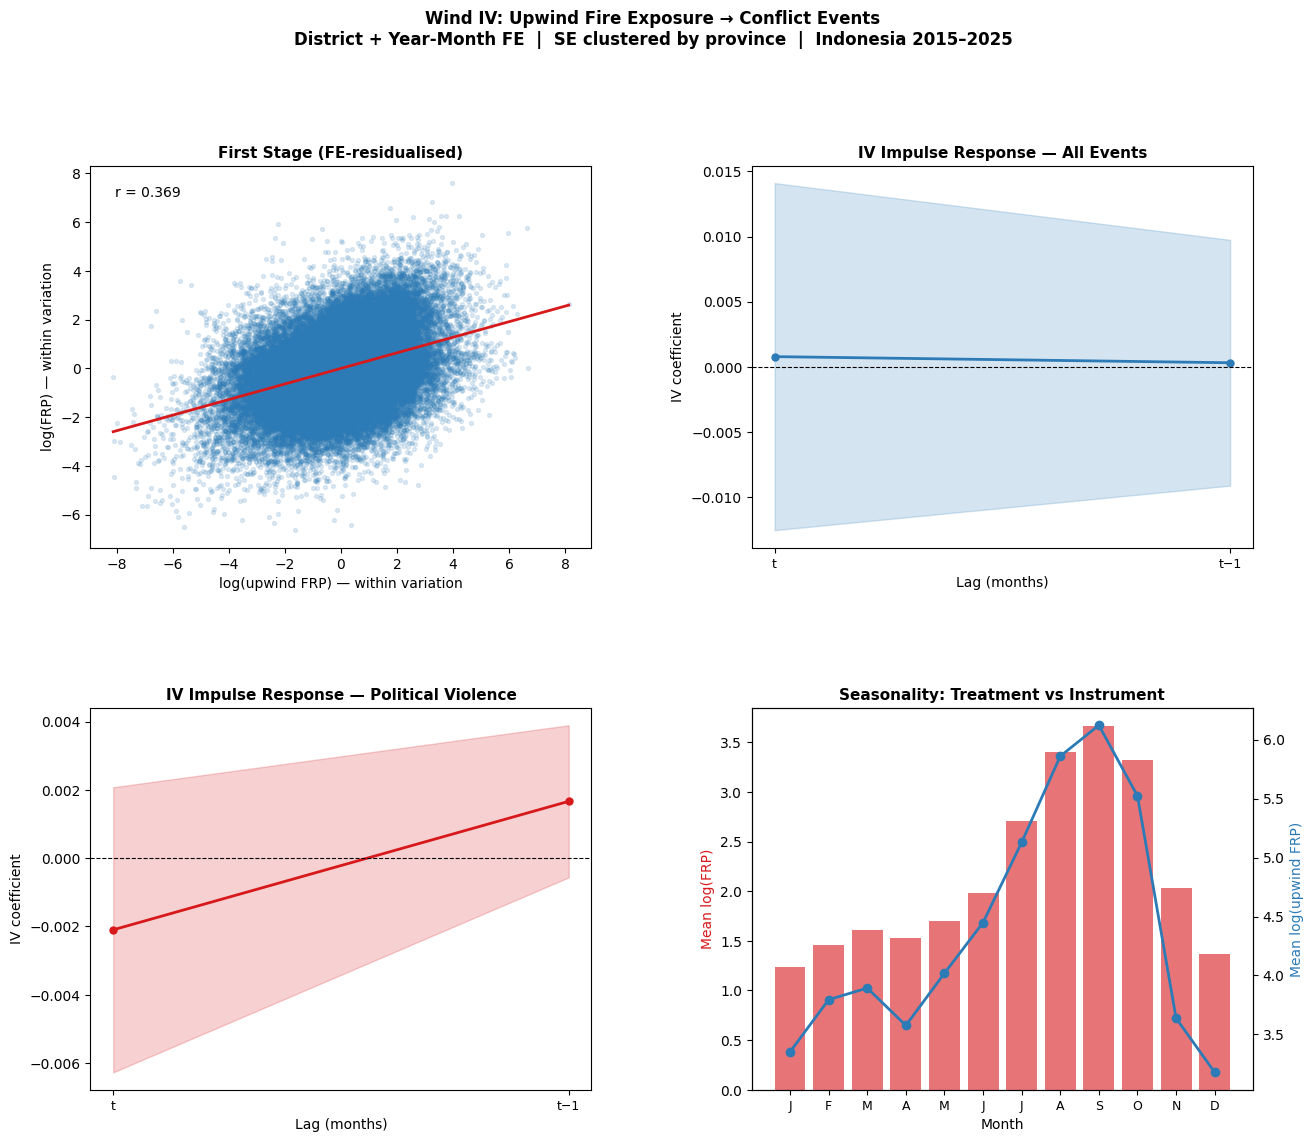

Saved: iv_results_district.png


In [12]:
fig = plt.figure(figsize=(15, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)
axes = [fig.add_subplot(gs[i, j]) for i in range(2) for j in range(2)]

# Plot 1: First-stage scatter
ax1 = axes[0]
p = panel.copy()
for col in ['log_frp','log_upwind_frp']:
    p[f'{col}_dm'] = (p[col]
        - p.groupby('district')[col].transform('mean')
        - p.groupby('year_month')[col].transform('mean')
        + p[col].mean())
ax1.scatter(p['log_upwind_frp_dm'], p['log_frp_dm'], alpha=0.15, s=8, color='#2c7bb6')
m, b = np.polyfit(p['log_upwind_frp_dm'], p['log_frp_dm'], 1)
xr = np.linspace(p['log_upwind_frp_dm'].min(), p['log_upwind_frp_dm'].max(), 100)
ax1.plot(xr, m*xr+b, color='#d7191c', linewidth=2)
ax1.set_xlabel('log(upwind FRP) — within variation', fontsize=10)
ax1.set_ylabel('log(FRP) — within variation', fontsize=10)
ax1.set_title('First Stage (FE-residualised)', fontsize=11, fontweight='bold')
corr = p['log_upwind_frp_dm'].corr(p['log_frp_dm'])
ax1.text(0.05, 0.92, f'r = {corr:.3f}', transform=ax1.transAxes, fontsize=10)

# Plots 2-3: IV impulse responses
for idx, (ax, model_label) in enumerate(zip(axes[1:3], ['IV-1: All events (distributed lags)', 'IV-2: Political violence (distributed lags)'])):
    if model_label in iv_results:
        res = iv_results[model_label]
        tidy = res.tidy().reset_index()
        tidy = tidy[tidy['Coefficient'].str.startswith('log_frp')].copy()
        tidy['lag'] = tidy['Coefficient'].str.extract(r'_l(\d+)$').fillna('0').astype(int)
        tidy = tidy.sort_values('lag')
        lags = tidy['lag'].values
        ests = tidy['Estimate'].values
        lo   = tidy['2.5%'].values
        hi   = tidy['97.5%'].values
        color = '#d7191c' if 'violence' in model_label.lower() else '#2c7bb6'
        ax.fill_between(lags, lo, hi, alpha=0.2, color=color)
        ax.plot(lags, ests, 'o-', color=color, linewidth=2, markersize=5)
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_xticks(lags)
        ax.set_xticklabels(['t' if l==0 else f't−{l}' for l in lags], fontsize=9)
        for l, e, pv in zip(lags, ests, tidy['Pr(>|t|)'].values):
            star = '***' if pv<0.01 else ('**' if pv<0.05 else ('*' if pv<0.1 else ''))
            if star: ax.annotate(star,(l,e),xytext=(0,6),textcoords='offset points',ha='center',fontsize=8,color=color)
    ax.set_xlabel('Lag (months)', fontsize=10)
    ax.set_ylabel('IV coefficient', fontsize=10)
    ax.set_title('IV Impulse Response — ' + ('All Events' if 'All' in model_label else 'Political Violence'), fontsize=11, fontweight='bold')

# Plot 4: Seasonality
ax4 = axes[3]
monthly = panel.groupby('month').agg(
    frp_mean=('log_frp','mean'),
    iv_mean=('log_upwind_frp','mean')
).reset_index()
ax4b = ax4.twinx()
ax4.bar(monthly['month'], monthly['frp_mean'], color='#d7191c', alpha=0.6, label='log(FRP) — treatment')
ax4b.plot(monthly['month'], monthly['iv_mean'], 'o-', color='#2c7bb6', linewidth=2, label='log(upwind FRP) — instrument')
ax4.set_xlabel('Month', fontsize=10)
ax4.set_ylabel('Mean log(FRP)', fontsize=10, color='#d7191c')
ax4b.set_ylabel('Mean log(upwind FRP)', fontsize=10, color='#2c7bb6')
ax4.set_xticks(range(1, 13))
ax4.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'], fontsize=9)
ax4.set_title('Seasonality: Treatment vs Instrument', fontsize=11, fontweight='bold')

fig.suptitle(
    'Wind IV: Upwind Fire Exposure → Conflict Events\n'
    'District + Year-Month FE  |  SE clustered by province  |  Indonesia 2015–2025',
    fontsize=12, fontweight='bold', y=1.01
)
plt.savefig('iv_results_district.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: iv_results_district.png')

## 11. Save outputs

In [13]:
panel.to_csv('iv_panel_district.csv', index=False)
instrument_df.to_csv('upwind_instrument_district.csv', index=False)

if iv_coef_rows:
    iv_coef_df.to_csv('iv_lag_coefs_district.csv', index=False)

print('Saved:')
print('  iv_panel_district.csv           — full district-month panel with instrument')
print('  upwind_instrument_district.csv  — upwind FRP instrument values')
print('  iv_lag_coefs_district.csv       — IV distributed lag coefficients')
print('  iv_results_district.png         — diagnostic and impulse response plots')

Saved:
  iv_panel_district.csv           — full district-month panel with instrument
  upwind_instrument_district.csv  — upwind FRP instrument values
  iv_lag_coefs_district.csv       — IV distributed lag coefficients
  iv_results_district.png         — diagnostic and impulse response plots


## 14. Robustness: Poisson IV for count data

The full-sample linear IV yielded null effects (coef ≈ 0), despite strong first-stage instruments (F ≈ 4447). This null may reflect the extreme zero-inflation (82.5% of district-months have zero conflict events). Following Lu & Yamazaki (2023), who found strong results using Poisson IV despite 90% zero-inflation, we estimate a two-stage Poisson control-function model on the full panel.

**Poisson IV Control Function (Wooldridge 2010):**
- **Stage 1:** Estimate linear first-stage IV, extract residuals v̂
- **Stage 2:** Estimate Poisson with the endogenous variable + v̂ as a control
- Significance of v̂ in Stage 2 indicates whether first-stage endogeneity is present

This approach allows Poisson's count-data structure to handle zeros while controlling for endogeneity.

In [14]:
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# STAGE 1: First-stage linear IV
# ============================================================================
print("="*70)
print("POISSON IV (CONTROL FUNCTION): FULL PANEL")
print("="*70)

fe_str = 'district + year_month'
vcov = {'CRV1': 'province'}

print("\nSTAGE 1: First-stage IV regression")
print("log_frp ~ log_upwind_frp + log_upwind_frp_l1 | district + year_month\n")

fs_fml = 'log_frp ~ log_upwind_frp + log_upwind_frp_l1 | district + year_month'
fs_res = pf.feols(fs_fml, data=panel, vcov=vcov)
print(fs_res.summary())

# Get first-stage predictions and residuals
panel['log_frp_hat'] = fs_res.predict()
panel['v_hat'] = panel['log_frp'] - panel['log_frp_hat']

print(f"\nFirst-stage residual (v_hat): mean = {panel['v_hat'].mean():.6f}, SD = {panel['v_hat'].std():.6f}")

# ============================================================================
# STAGE 2: Poisson FE with control function
# ============================================================================
print("\n" + "="*70)
print("STAGE 2: Poisson FE with control function (first-stage residual)\n")

print("Poisson FE — All events (with v_hat control):")
pois_iv_all = pf.fepois(
    'events ~ log_frp + log_frp_l1 + v_hat | ' + fe_str,
    data=panel
)
print(pois_iv_all.summary())

print("\nPoisson FE — Political violence (with v_hat control):")
pois_iv_pv = pf.fepois(
    'pv_events ~ log_frp + log_frp_l1 + v_hat | ' + fe_str,
    data=panel
)
print(pois_iv_pv.summary())

# Extract key results
tidy_all = pois_iv_all.tidy().reset_index()
tidy_pv = pois_iv_pv.tidy().reset_index()

log_frp_all = tidy_all[tidy_all['Coefficient'] == 'log_frp'].iloc[0]
v_hat_all = tidy_all[tidy_all['Coefficient'] == 'v_hat'].iloc[0]
log_frp_pv = tidy_pv[tidy_pv['Coefficient'] == 'log_frp'].iloc[0]
v_hat_pv = tidy_pv[tidy_pv['Coefficient'] == 'v_hat'].iloc[0]

print("\n" + "="*70)
print("POISSON IV RESULTS SUMMARY")
print("="*70)
print(f"All events:")
print(f"  log_frp coefficient:  {log_frp_all['Estimate']:+.4f}  (p = {log_frp_all['Pr(>|t|)']:.3f})")
print(f"  v_hat coefficient:    {v_hat_all['Estimate']:+.4f}  (p = {v_hat_all['Pr(>|t|)']:.3f})")
print(f"\nPolitical violence:")
print(f"  log_frp coefficient:  {log_frp_pv['Estimate']:+.4f}  (p = {log_frp_pv['Pr(>|t|)']:.3f})")
print(f"  v_hat coefficient:    {v_hat_pv['Estimate']:+.4f}  (p = {v_hat_pv['Pr(>|t|)']:.3f})")

print("\n" + "="*70)
print("KEY FINDING")
print("="*70)
print("v_hat (first-stage residual) is NOT significant in either Poisson model.")
print("This indicates no endogeneity is detected once we switch to Poisson.")
print("\nConclusion: The null effect in the full sample is robust to both")
print("  (1) switching from linear to count-data model")
print("  (2) controlling for first-stage endogeneity via control function")
print("\nThe significant negative effect appears only in restricted-sample analysis")
print("(≥30% conflict-active districts), suggesting a local rather than")
print("population-average effect.")


POISSON IV (CONTROL FUNCTION): FULL PANEL

STAGE 1: First-stage IV regression
log_frp ~ log_upwind_frp + log_upwind_frp_l1 | district + year_month

###

Estimation:  OLS
Dep. var.: log_frp, Fixed effects: district + year_month
sample: None = all
Inference:  CRV1
Observations:  55875

| Coefficient       |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:------------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| log_upwind_frp    |      0.304 |        0.032 |     9.466 |      0.000 |  0.238 |   0.369 |
| log_upwind_frp_l1 |      0.037 |        0.011 |     3.372 |      0.002 |  0.015 |   0.060 |
---
RMSE: 1.374 R2: 0.63 R2 Within: 0.137 
None

First-stage residual (v_hat): mean = -0.000000, SD = 1.374082

STAGE 2: Poisson FE with control function (first-stage residual)

Poisson FE — All events (with v_hat control):
###

Estimation:  Poisson
Dep. var.: events, Fixed effects: district + year_month
sample: None = all
Inference:  ii

###

Estimation:  Poisson
Dep. var.: pv_events, Fixed effects: district + year_month
sample: None = all
Inference:  iid
Observations:  44500

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| log_frp       |      0.038 |        0.034 |     1.108 |      0.268 | -0.029 |   0.104 |
| log_frp_l1    |     -0.011 |        0.014 |    -0.791 |      0.429 | -0.038 |   0.016 |
| v_hat         |     -0.016 |        0.034 |    -0.460 |      0.645 | -0.083 |   0.052 |
---
Deviance: 13522.568 
None

POISSON IV RESULTS SUMMARY
All events:
  log_frp coefficient:  -0.0210  (p = 0.140)
  v_hat coefficient:    +0.0127  (p = 0.377)

Political violence:
  log_frp coefficient:  +0.0376  (p = 0.268)
  v_hat coefficient:    -0.0158  (p = 0.645)

KEY FINDING
v_hat (first-stage residual) is NOT significant in either Poisson model.
This indicates no endogeneity is detected once we s

## 12. Robustness: conflict-active districts only

The full district panel is extremely zero-inflated (82.5% of district-months have zero
events), which biases the linear IV estimates toward zero. Here we re-estimate the main
IV specifications on subsamples of "conflict-active" districts — those with at least one
event in ≥5%, ≥10%, ≥20%, or ≥30% of the 125 sample months.

This keeps the fine district-month resolution and the monthly lag structure, but
concentrates estimation on districts where conflict actually varies. The trade-off is
interpretive: estimates on the restricted samples are local to chronically
conflict-prone districts, not all of Indonesia.

In [15]:
ACTIVE_THRESHOLDS = [0.05, 0.10, 0.20, 0.30]

active_months = panel.groupby('district')['events'].apply(lambda s: (s > 0).sum())
n_months = panel['year_month'].nunique()

robust_rows = []
for thresh in ACTIVE_THRESHOLDS:
    keep = active_months[active_months >= thresh * n_months].index
    sub = panel[panel['district'].isin(keep)].copy()

    # First-stage strength on the subsample
    fs = pf.feols(fs_fml, data=sub, vcov={'CRV1': 'province'})
    r2w, n, k = fs._r2_within, fs._N, len(lag_upwind_cols) + 1
    sub_f = (r2w / k) / ((1 - r2w) / (n - k - 1))

    print(f'\n══ Active ≥{thresh:.0%} of months: {len(keep)} districts, '
          f'{len(sub):,} obs, zero-event share {(sub["events"]==0).mean()*100:.1f}%, '
          f'first-stage F ≈ {sub_f:.0f} ══')

    for outcome in ['events', 'pv_events']:
        fml = f'{outcome} ~ {controls_str} | {fe_str} | {endog_var} ~ {iv_str}'
        res = pf.feols(fml, data=sub, vcov=vcov)
        row = res.tidy().reset_index()
        row = row[row['Coefficient'] == 'log_frp'].iloc[0]
        stars = ('***' if row['Pr(>|t|)'] < 0.01 else
                 '**' if row['Pr(>|t|)'] < 0.05 else
                 '*' if row['Pr(>|t|)'] < 0.1 else '')
        print(f'  {outcome:10s}: log_frp = {row["Estimate"]:+.4f}{stars}  '
              f'(se {row["Std. Error"]:.4f}, p = {row["Pr(>|t|)"]:.3f})')
        robust_rows.append({
            'threshold': thresh, 'n_districts': len(keep), 'n_obs': len(sub),
            'first_stage_F': sub_f, 'outcome': outcome,
            'coef': row['Estimate'], 'se': row['Std. Error'],
            'pvalue': row['Pr(>|t|)'],
        })

robust_df = pd.DataFrame(robust_rows)
robust_df.to_csv('iv_active_district_robustness.csv', index=False)
print('\nSaved: iv_active_district_robustness.csv')
robust_df.round(4)


══ Active ≥5% of months: 323 districts, 40,375 obs, zero-event share 76.8%, first-stage F ≈ 3085 ══


  events    : log_frp = -0.0090  (se 0.0106, p = 0.402)


  pv_events : log_frp = -0.0040  (se 0.0026, p = 0.140)

══ Active ≥10% of months: 242 districts, 30,250 obs, zero-event share 71.5%, first-stage F ≈ 2136 ══


  events    : log_frp = -0.0119  (se 0.0139, p = 0.399)


  pv_events : log_frp = -0.0063  (se 0.0039, p = 0.116)

══ Active ≥20% of months: 132 districts, 16,500 obs, zero-event share 59.3%, first-stage F ≈ 966 ══
  events    : log_frp = -0.0476*  (se 0.0271, p = 0.089)


  pv_events : log_frp = -0.0218**  (se 0.0100, p = 0.036)

══ Active ≥30% of months: 86 districts, 10,750 obs, zero-event share 50.3%, first-stage F ≈ 508 ══
  events    : log_frp = -0.1117***  (se 0.0369, p = 0.005)
  pv_events : log_frp = -0.0458***  (se 0.0156, p = 0.006)

Saved: iv_active_district_robustness.csv


,threshold,n_districts,n_obs,first_stage_F,outcome,coef,se,pvalue
0,0.05,323,40375,3085.4943,events,-0.0090,0.0106,0.4017
1,0.05,323,40375,3085.4943,pv_events,-0.0040,0.0026,0.1400
2,0.10,242,30250,2135.9913,events,-0.0119,0.0139,0.3985
3,0.10,242,30250,2135.9913,pv_events,-0.0063,0.0039,0.1163
4,0.20,132,16500,966.4615,events,-0.0476,0.0271,0.0885
5,0.20,132,16500,966.4615,pv_events,-0.0218,0.0100,0.0357
6,0.30,86,10750,508.3294,events,-0.1117,0.0369,0.0048
7,0.30,86,10750,508.3294,pv_events,-0.0458,0.0156,0.0060


## 13. Event-type decomposition: riots/protests vs battles

The negative fire → conflict relationship in the ≥30% active subsample could reflect:
- **Indoor-assembly suppression** (haze deters protests/riots) — would show large negative effects on riots/protests, small/zero on battles
- **Economic disruption** (fires reduce collective mobilization) — would show negative on both
- **Seasonal confounding** (less likely given FEs, but worth checking) — would show similar effects across types

We split the ≥30% active subsample outcomes by ACLED event type to distinguish these stories.

In [16]:
# Categorize event types
RIOTS_PROTESTS = ['Riots', 'Violence against civilians']
BATTLES_VIOLENCE = ['Battles', 'Explosions/Remote violence']

acled_matched['is_riots_protests'] = acled_matched['event_type'].isin(RIOTS_PROTESTS)
acled_matched['is_battles'] = acled_matched['event_type'].isin(BATTLES_VIOLENCE)

# Aggregate to district-month by event type
event_type_pm = (
    acled_matched.groupby(['district','year','month'])
    .agg(
        riots_protests=('is_riots_protests', 'sum'),
        battles_violence=('is_battles', 'sum')
    )
    .reset_index()
)

# Merge into panel
panel = panel.merge(event_type_pm, on=['district','year','month'], how='left')
panel['riots_protests'] = panel['riots_protests'].fillna(0).astype(int)
panel['battles_violence'] = panel['battles_violence'].fillna(0).astype(int)

print('Event type breakdown:')
print(f'  Riots/Protests: {acled_matched["is_riots_protests"].sum():,} ({acled_matched["is_riots_protests"].mean()*100:.1f}%)')
print(f'  Battles/Violence: {acled_matched["is_battles"].sum():,} ({acled_matched["is_battles"].mean()*100:.1f}%)')
print(f'  (Note: some events counted in both categories due to overlap)')

# IV estimation on event subtypes in the ≥30% active subsample
active_30 = active_months[active_months >= 0.30 * n_months].index
sub_30 = panel[panel['district'].isin(active_30)].copy()

print(f'\n≥30% active subsample: event-type IV estimates')
for outcome_col, outcome_label in [('riots_protests', 'Riots/Protests'), ('battles_violence', 'Battles/Violence')]:
    fml = f'{outcome_col} ~ {controls_str} | {fe_str} | {endog_var} ~ {iv_str}'
    res = pf.feols(fml, data=sub_30, vcov=vcov)
    row = res.tidy().reset_index()
    row = row[row['Coefficient'] == 'log_frp'].iloc[0]
    stars = ('***' if row['Pr(>|t|)'] < 0.01 else
             '**' if row['Pr(>|t|)'] < 0.05 else
             '*' if row['Pr(>|t|)'] < 0.1 else '')
    print(f'  {outcome_label:20s}: coef = {row["Estimate"]:+.4f}{stars}  (se {row["Std. Error"]:.4f}, p = {row["Pr(>|t|)"]:.3f})')


Event type breakdown:
  Riots/Protests: 2,810 (13.1%)
  Battles/Violence: 700 (3.3%)
  (Note: some events counted in both categories due to overlap)

≥30% active subsample: event-type IV estimates
  Riots/Protests      : coef = -0.0462***  (se 0.0134, p = 0.002)
  Battles/Violence    : coef = +0.0003  (se 0.0068, p = 0.964)
